In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Import all algorithms for exploration
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import seaborn as sns
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import os
import mlflow
import mlflow.sklearn
import joblib
import warnings

import streamlit as st

warnings.filterwarnings('ignore')



In [2]:

df = pd.read_csv('C:\\Users\\Kolade\\Desktop\\DayFigurez internship\\Datasets\\Loan_default.csv\\Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [4]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [5]:
df = df.drop(["LoanID"], axis=1)

In [6]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
print(df["Education"].unique())
print(df["EmploymentType"].unique())
print(df["MaritalStatus"].unique())
print(df["HasMortgage"].unique())
print(df["HasDependents"].unique())
print(df["LoanPurpose"].unique())
print(df["HasCoSigner"].unique())


["Bachelor's" "Master's" 'High School' 'PhD']
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']
['Divorced' 'Married' 'Single']
['Yes' 'No']
['Yes' 'No']
['Other' 'Auto' 'Business' 'Home' 'Education']
['Yes' 'No']


In [8]:
#  Replace values with good ones
# Exploratory
# Do count plot of each categorical var
# Do continous plot to see spread for each numerical
# Do the pair plot, between numericsl vars
# Box plot for numerical vars
# corr matrix
# Remove the ones I dont need
# Do the dummy stuff abi encoder
# u decide x and y
# split then scale the ones that need it
# First do one model, then check, then run grid searchcv
# Check the metrics for best one well
# do mlflow
# save the model, then do the same for the rest of the models, then compare the results and pick the best one
# Streamlit


In [9]:
df["Education"] = df["Education"].replace({"Bachelor's": "Bachelors", "Master's": "Masters"})
df["EmploymentType"] = df["EmploymentType"].replace({"Full-time": "Full time", "Self-employed": "Self employed"})


In [10]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelors,Full time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Masters,Full time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Masters,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelors,Unemployed,Divorced,No,Yes,Auto,No,0


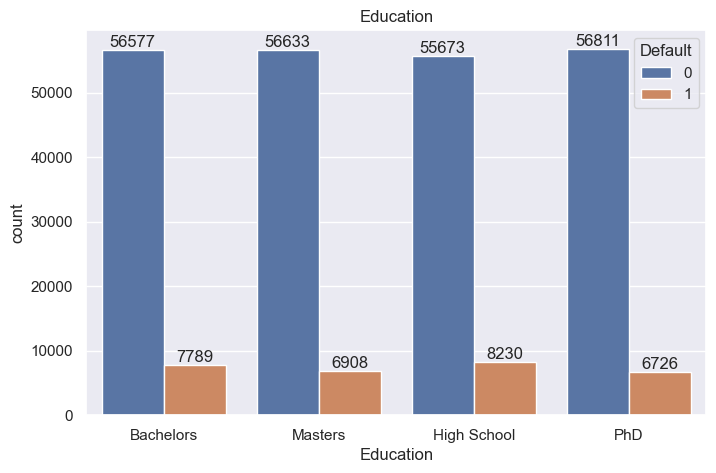

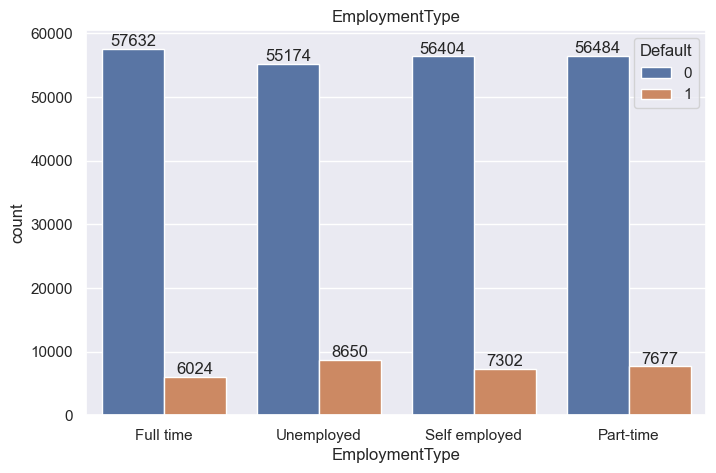

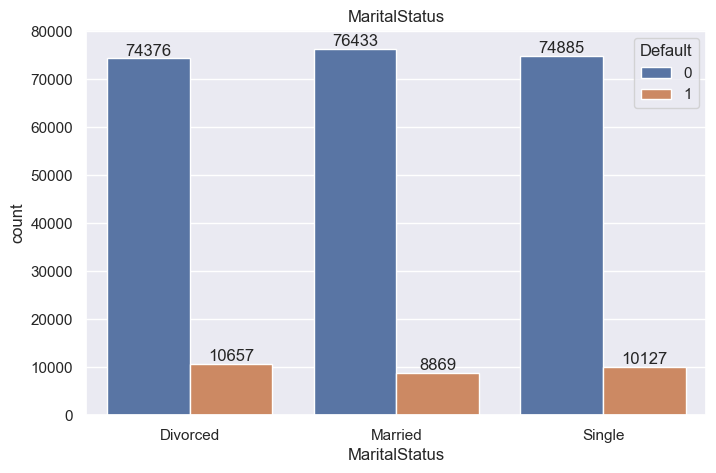

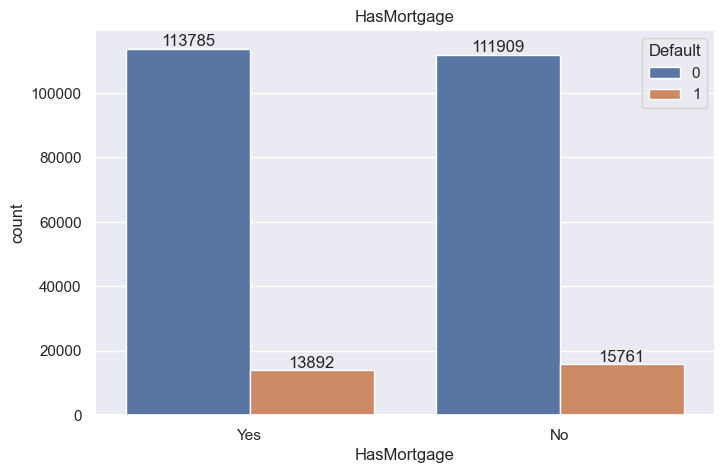

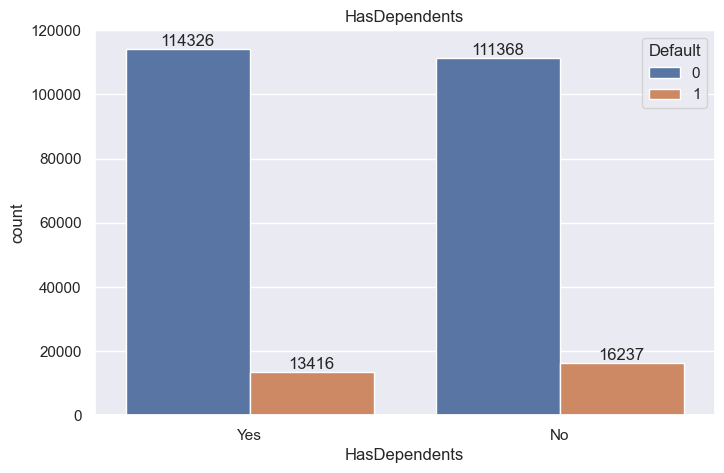

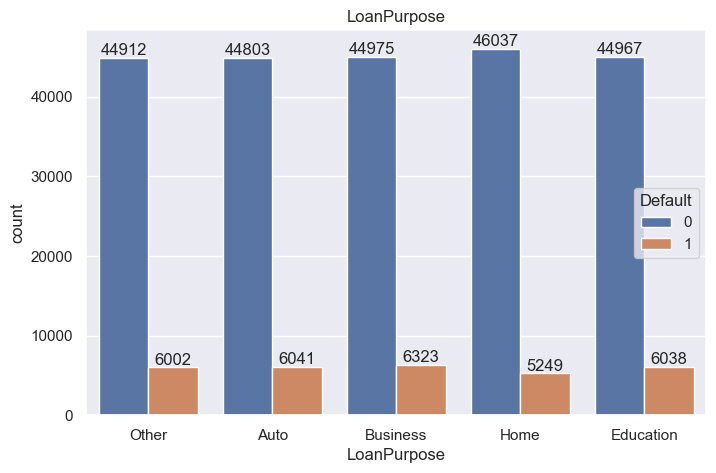

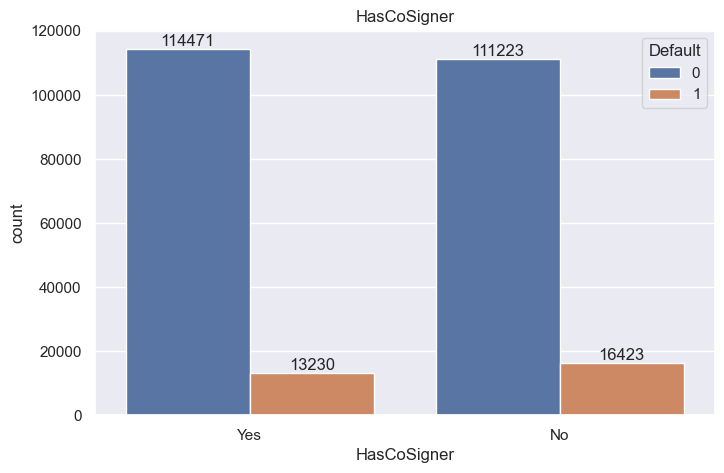

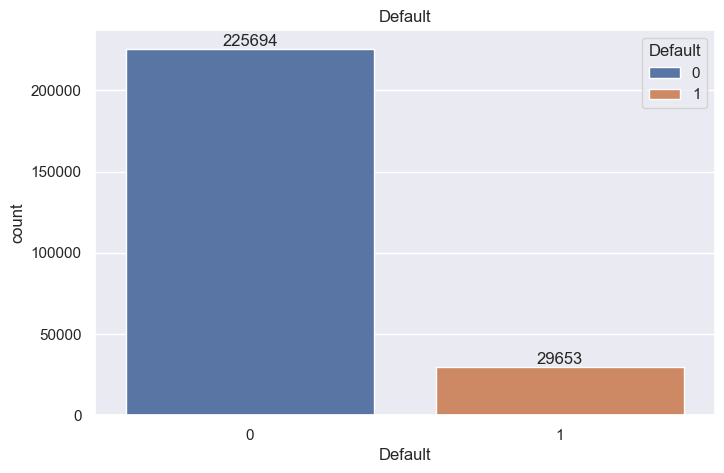

In [11]:
# sns.countplot(x='Outcome', data=df_3)
# plt.title('Distribution of Diabetes Outcomes')

categories = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

sns.set(rc={'figure.figsize':(8,5)})

for c in categories:

    ax = sns.countplot(x=c, data=df, hue='Default')
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(c)
    plt.show()

In [12]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelors,Full time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Masters,Full time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Masters,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelors,Unemployed,Divorced,No,Yes,Auto,No,0


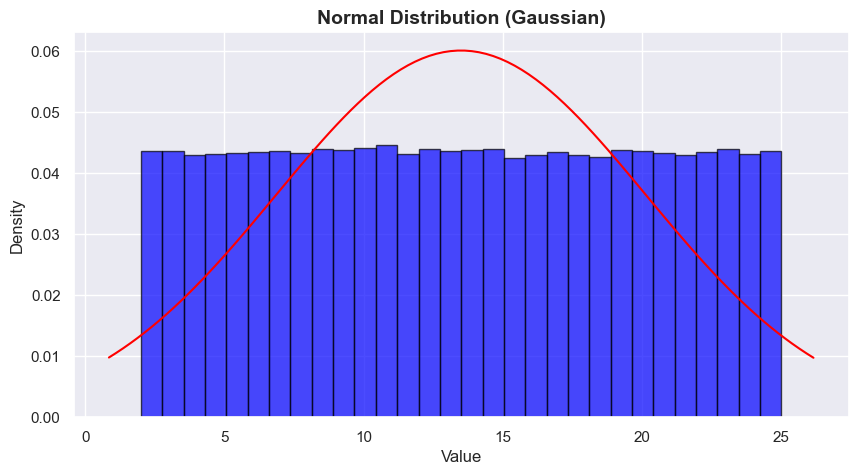

In [13]:
# 0 means they cant be given the loan, 1 means they can be given the loan, so we are trying to predict the default column, which is the target variable, and the rest are the features
from scipy.stats import norm

# normal_data = np.random.normal(loc=100, scale=15, size=1000)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(df["InterestRate"], bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')

mu, std = norm.fit(df["InterestRate"])

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = norm.pdf(x, mu, std)

plt.plot(x, p, color='red')

plt.title('Normal Distribution (Gaussian)', fontsize=14, fontweight='bold')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

# print(f"Mean: {df["Age"].mean():.2f}")
# print(f"Std Dev: {df["Age"].std():.2f}")


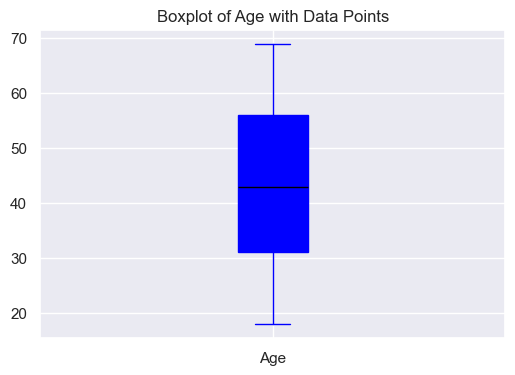

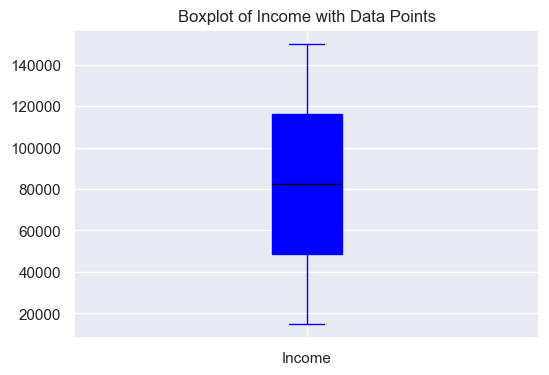

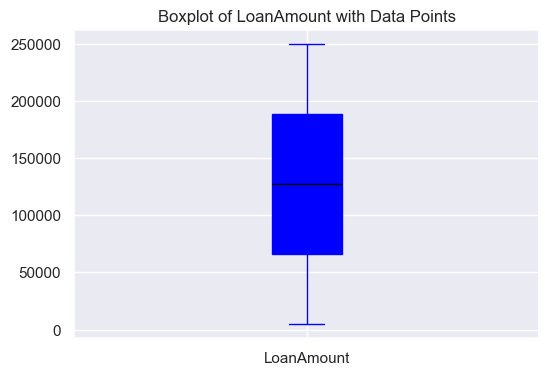

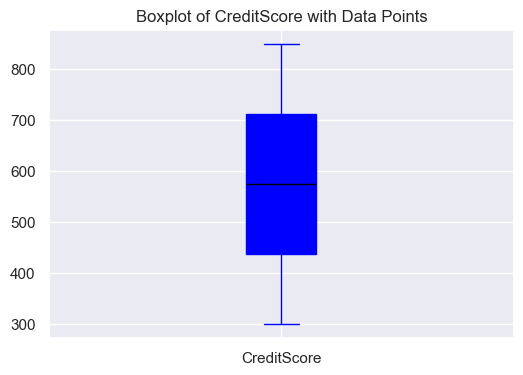

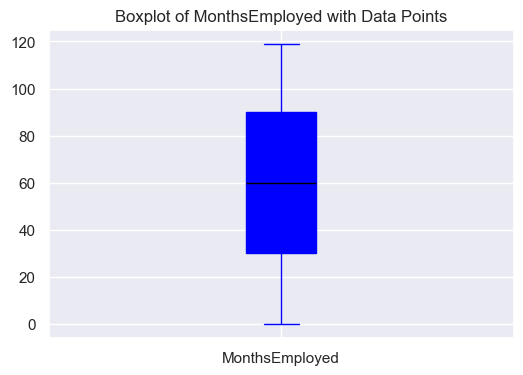

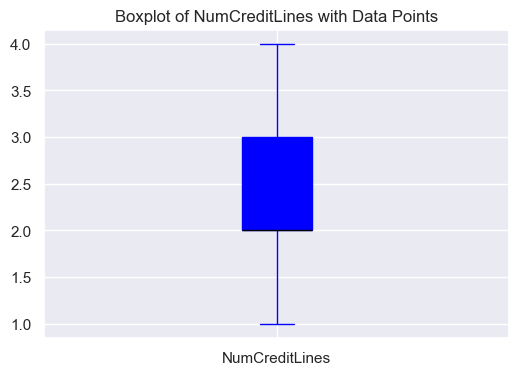

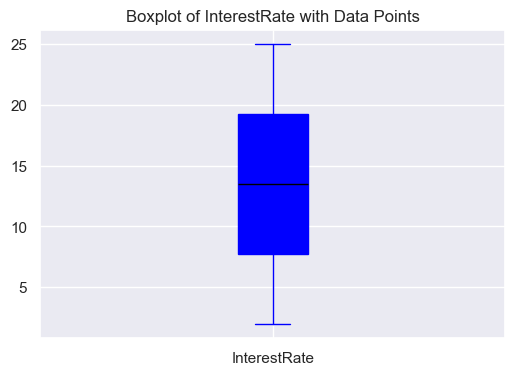

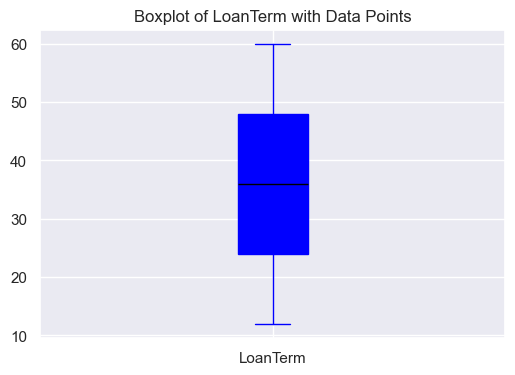

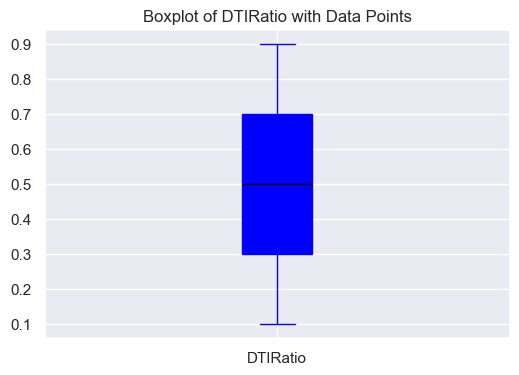

In [14]:

cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

for col in cols:
    plt.figure(figsize=(6, 4))

    plt.boxplot(
        df[col], 
        patch_artist=True,
        boxprops=dict(facecolor='blue', color='blue'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='blue'),
        capprops=dict(color='blue')
    )

    # x = np.random.normal(1, 0.04, size=len(df[col]))
    # plt.scatter(x, df[col], color='red', alpha=0.6)

    plt.title(f"Boxplot of {col} with Data Points")
    plt.xticks([1], [col])

    plt.show()

In [15]:
# They are all pretty much normal
# No outliers

In [16]:
# g = sns.pairplot(df)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes: float64

In [18]:
final_df = pd.get_dummies(df, columns =['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose'])
final_df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,EmploymentType_Self employed,EmploymentType_Unemployed,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,Yes,...,False,False,True,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,No,...,False,False,False,True,False,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,Yes,...,False,True,True,False,False,True,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,No,...,False,False,False,True,False,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,No,...,False,True,True,False,False,True,False,False,False,False


In [19]:
final_df["HasMortgage"] = final_df["HasMortgage"].replace({"Yes": 1, "No": 0})
final_df["HasDependents"] = final_df["HasDependents"].replace({"Yes": 1, "No": 0})
final_df["HasCoSigner"] = final_df["HasCoSigner"].replace({"Yes": 1, "No": 0})


In [20]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   HasMortgage                   255347 non-null  int64  
 10  HasDependents                 255347 non-null  int64  
 11  HasCoSigner                   255347 non-null  int64  
 12  Default                       255347 non-nul

In [21]:
# Do the encoder stuff

x = final_df.drop("Default", axis=1)
y = final_df["Default"]


In [22]:
dt_model = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=None, min_samples_leaf=2, n_estimators=100)
dt_model.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
for i, column in enumerate(final_df.drop('Default', axis = 1)):
    # print(column)
    print(f"{column}: {dt_model.feature_importances_[i]:.3f}")

    fi = pd.DataFrame({'Feature': [column], 'Importance Score': [dt_model.feature_importances_[i]]})
    # print(fi)
    try:
        final_fi2 = pd.concat([final_fi2, fi], ignore_index=True)
    except:
        final_fi2 = fi
    
final_fi2 = final_fi2.sort_values('Importance Score', ascending=False)
final_fi2

Age: 0.133
Income: 0.120
LoanAmount: 0.106
CreditScore: 0.088
MonthsEmployed: 0.099
NumCreditLines: 0.028
InterestRate: 0.129
LoanTerm: 0.035
DTIRatio: 0.078
HasMortgage: 0.012
HasDependents: 0.012
HasCoSigner: 0.012
Education_Bachelors: 0.010
Education_High School: 0.010
Education_Masters: 0.010
Education_PhD: 0.010
EmploymentType_Full time: 0.008
EmploymentType_Part-time: 0.009
EmploymentType_Self employed: 0.009
EmploymentType_Unemployed: 0.008
MaritalStatus_Divorced: 0.010
MaritalStatus_Married: 0.009
MaritalStatus_Single: 0.010
LoanPurpose_Auto: 0.010
LoanPurpose_Business: 0.009
LoanPurpose_Education: 0.010
LoanPurpose_Home: 0.009
LoanPurpose_Other: 0.009


,Feature,Importance Score
0,Age,0.132893
6,InterestRate,0.128809
1,Income,0.119532
2,LoanAmount,0.106232
4,MonthsEmployed,0.099434
3,CreditScore,0.087506
8,DTIRatio,0.078393
7,LoanTerm,0.035024
5,NumCreditLines,0.028462
9,HasMortgage,0.012251


In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [33]:
algorithms = {
    "Logistic_Regression": {
        "model": LogisticRegression(random_state=42, max_iter=10000),
        "params": {'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'distance'],'penalty': ['l1', 'l2']}
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    # "SVC": {
    #     "model": SVC(random_state=42),
    #     "params": {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'class_weight': [None, 'balanced']}
    # },
    "Random_Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'class_weight': [None, 'balanced'], 'min_samples_leaf': [1, 2, 4]}
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        "params": {
            'n_estimators': [50, 100],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'gamma': [0, 1]
        }
    },
    "Decision_Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {'criterion': ['gini', 'entropy'], 'class_weight': [None, 'balanced'], 'max_depth': [5, 10, 20]}
    }
}

champion_name = ""
champion_model = None
champion_accuracy = 0.0

print("Starting Algorithm Exploration...\n" + "-"*40)

Starting Algorithm Exploration...
----------------------------------------


In [34]:
for algo_name, config in algorithms.items():
    print(f"Training and tuning {algo_name}...")
    
    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=5,
        n_jobs=-1,
        scoring='accuracy'
    )
    
    # Fit the model
    grid_search.fit(x_train, y_train)
    
    # Extract best model and parameters for this specific algorithm
    best_model_for_algo = grid_search.best_estimator_
    best_params_for_algo = grid_search.best_params_
    
    # Evaluate on the test set
    y_pred = best_model_for_algo.predict(x_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    f1_accuracy = f1_score(y_test, y_pred)

    print(f"[{algo_name}] Best Params: {best_params_for_algo}")
    print(f"[{algo_name}] Test Accuracy: {test_accuracy * 100:.2f}%\n")
    
    # Check if this is the best model overall
    if test_accuracy > champion_accuracy:
        champion_accuracy = test_accuracy
        champion_model = best_model_for_algo
        champion_name = algo_name

print("-" * 40)
print(f"🏆 CHAMPION MODEL: {champion_name} with {champion_accuracy * 100:.2f}% accuracy!")


Training and tuning Logistic_Regression...
[Logistic_Regression] Best Params: {'C': 0.1, 'class_weight': None, 'penalty': 'l2'}
[Logistic_Regression] Test Accuracy: 88.53%

Training and tuning KNN...
[KNN] Best Params: {'n_neighbors': 9, 'weights': 'uniform'}
[KNN] Test Accuracy: 88.07%

Training and tuning Random_Forest...
[Random_Forest] Best Params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
[Random_Forest] Test Accuracy: 88.55%

Training and tuning XGBoost...
[XGBoost] Best Params: {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
[XGBoost] Test Accuracy: 88.66%

Training and tuning Decision_Tree...
[Decision_Tree] Best Params: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5}
[Decision_Tree] Test Accuracy: 88.49%

----------------------------------------
🏆 CHAMPION MODEL: XGBoost with 88.66% accuracy!


In [27]:
# y_pred_svc = pipeline.predict(x_train)
# y_pred_test = pipeline.predict(x_test)

In [ ]:
# print(classification_report(y_train, y_pred_svc))
# print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.61      0.06      0.11      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070



In [ ]:
# "SVC": {
#         "model": SVC(random_state=42),
#         "params": {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'class_weight': [None, 'balanced']}
#     },

In [35]:
# model_svc = GradientBoostingClassifier(random_state=42)
# model_svc.fit(x_train, y_train)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('gbc', XGBClassifier(random_state=42, n_estimators=100, max_depth=5, colsample_bytree = 0.8,
                                       gamma = 1, learning_rate = 0.1, subsample = 1.0))
])
pipeline.fit(x_train, y_train)
# [XGBoost] Test Accuracy: 88.66%


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'


In [36]:
y_pred_svc = pipeline.predict(x_train)
y_pred_test = pipeline.predict(x_test)

In [37]:
print(classification_report(y_train, y_pred_svc))
print(classification_report(y_test, y_pred_test))


              precision    recall  f1-score   support

           0       0.89      0.99      0.94    180555
           1       0.51      0.10      0.16     23722

    accuracy                           0.88    204277
   macro avg       0.70      0.54      0.55    204277
weighted avg       0.85      0.88      0.85    204277

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.51      0.10      0.16      5931

    accuracy                           0.88     51070
   macro avg       0.70      0.54      0.55     51070
weighted avg       0.85      0.88      0.85     51070



In [ ]:
# Check the metrics for the best one well
# print(accuracy_score(y_test, y_pred_test))

0.8797532798120227


In [ ]:
# # Import necessary libraries
# from sklearn.datasets import make_classification
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from imblearn.over_sampling import SMOTE
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, f1_score

# # Generate a sample imbalanced dataset
# X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=1, weights=[0.9, 0.1], random_state=42)

# # Split the dataset into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Apply SMOTE oversampling
# smote = SMOTE(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# # Train a logistic regression model with class weighting
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# model = LogisticRegression(class_weight='balanced', random_state=42)
# model.fit(X_train_scaled, y_train)

# model_smote = LogisticRegression(random_state=42)
# model_smote.fit(X_train_smote, y_train_smote)

# # Evaluate the models
# y_pred = model.predict(X_test_scaled)
# y_pred_smote = model_smote.predict(X_test_scaled)

# print("Original dataset (class weighting):")
# print(classification_report(y_test, y_pred))
# print(f"F1-score: {f1_score(y_test, y_pred, average='macro')}")

# print("\nSMOTE oversampling:")
# print(classification_report(y_test, y_pred_smote))
# print(f"F1-score: {f1_score(y_test, y_pred_smote, average='macro')}")
# # This code generates an imbalanced dataset, applies SMOTE oversampling, 
# # and trains logistic regression models with and without SMOTE. 
# # The performance is evaluated using classification reports and F1-scores.

Original dataset (class weighting):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       179
           1       0.86      0.86      0.86        21

    accuracy                           0.97       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.97      0.97      0.97       200

F1-score: 0.9201915403032721

SMOTE oversampling:
              precision    recall  f1-score   support

           0       1.00      0.10      0.18       179
           1       0.12      1.00      0.21        21

    accuracy                           0.20       200
   macro avg       0.56      0.55      0.19       200
weighted avg       0.91      0.20      0.19       200

F1-score: 0.19481883423770346


In [93]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelors,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Masters,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Masters,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelors,Divorced,No,Yes,Auto,No,0


In [ ]:
# Age
# Income
# loanAmount
# CreditScore
# MonthsEmployed
# NumCreditLines
# InterestRate
# LoanTerm
# DTIRatio
# Education
# MaritalStatus
# HasMortgage
# HasDependents
# LoanPurpose
# HasCoSigner

def get_user_input():
    age = st.sidebar.number_input("Enter Age: ", min_value=0, max_value=120, value=30)
    income = st.sidebar.number_input("Enter Income: ", min_value=0, value=50000)
    loan_amount = st.sidebar.number_input("Enter Loan Amount: ", min_value=0, value=10000)
    credit_score = st.sidebar.number_input("Enter Credit Score: ", min_value=300, value=650)
    months_employed = st.sidebar.number_input("Enter Months Employed: ", min_value=0, value=12)
    num_credit_lines = st.sidebar.number_input("Enter Number of Credit Lines: ", min_value=0, value=3)
    interest_rate = st.sidebar.number_input("Enter Interest Rate: ", min_value=0.0, value=10.0)
    loan_term = st.sidebar.number_input("Enter Loan Term (in months): ", min_value=0, value=3)
    dti_ratio = st.sidebar.number_input("Enter Debt-to-Income Ratio: ", min_value=0.0, value=3.0)
    
    education = st.sidebar.selectbox('Enter Education',['Bachelors', 'Masters', 'PhD', 'High School'])
    marital_status = st.sidebar.selectbox('Enter Marital Status',['Single', 'Married', 'Divorced'])
    has_mortgage = st.sidebar.selectbox('Has Mortgage?',['Yes', 'No'])
    has_mortgage = 1 if has_mortgage == "Yes" else 0
    has_dependents = st.sidebar.selectbox('Has Dependents?',['Yes', 'No'])
    has_dependents = 1 if has_dependents == "Yes" else 0
    loan_purpose = st.sidebar.selectbox('Enter Loan Purpose',['Home', 'Car', 'Education', 'Personal'])
    has_cosigner = st.sidebar.selectbox('Has Co-Signer?',['Yes', 'No'])
    has_cosigner = 1 if has_cosigner == "Yes" else 0
    
    user_data = {
        'Age': age,
        'Income': income,
        'LoanAmount': loan_amount,
        'CreditScore': credit_score,
        'MonthsEmployed': months_employed,
        'NumCreditLines': num_credit_lines,
        'InterestRate': interest_rate,
        'LoanTerm': loan_term,
        'DTIRatio': dti_ratio,

        
        f'Education_{education}': 1,
        f'MaritalStatus_{marital_status}': 1,
        'HasMortgage': has_mortgage,
        'HasDependents': has_dependents,
        f'LoanPurpose_{loan_purpose}': 1,
        'HasCoSigner': has_cosigner
    }
    return user_data

user_data = get_user_input()
user_data
    
    # return pd.DataFrame([user_data])

In [ ]:
def prepare_input(data, feature_list):
    input_data = {feature: data.get(feature, 0) for feature in feature_list}
    return np.array([list(input_data.values())])

features = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio',
    'HasMortgage',
    'HasDependents',
    'HasCoSigner',
    'Education_Bachelors',
    'Education_High School',
    'Education_Masters',
    'Education_PhD',
    'MaritalStatus_Divorced',
    'MaritalStatus_Married',
    'MaritalStatus_Single',
    'LoanPurpose_Auto',
    'LoanPurpose_Business',
    'LoanPurpose_Education',
    'LoanPurpose_Home',
    'LoanPurpose_Other'
]

input_array = prepare_input(user_data, features)
input_array


In [ ]:
prediction = champion_model.predict(input_array)
prediction

In [ ]:
st.set_page_config(page_title="Loan Classification", layout="wide")
# , page_icon=":car:"



st.markdown("<h1 style='text-align: center;'>Loan Classification App</h1>", unsafe_allow_html=True)